正在处理数据集：10x-Multiome-Pbmc10k
✅ 数据集10x-Multiome-Pbmc10k处理完成，前3行综合得分预览：
      Embedding  Repeat Bio conservation（均值） Batch correction（均值）  \
0       UniDISA       1             0.948085             0.977497   
1       MaxFuse       1             0.797764             0.706751   
2  scConfluence       1              0.90612             0.462085   

  Overall integration score  
0                   0.95985  
1                  0.761359  
2                  0.728506  

正在处理数据集：D25
✅ 数据集D25处理完成，前3行综合得分预览：
      Embedding  Repeat Bio conservation（均值） Batch correction（均值）  \
0       UniDISA       1                  1.0             0.844893   
1       MaxFuse       1             0.767632              0.57725   
2  scConfluence       1             0.554636             0.362823   

  Overall integration score  
0                  0.937957  
1                  0.691479  
2                  0.477911  

正在处理数据集：D31
✅ 数据集D31处理完成，前3行综合得分预览：
      Embedding  Repeat Bio conservation（均值） Batch correction（

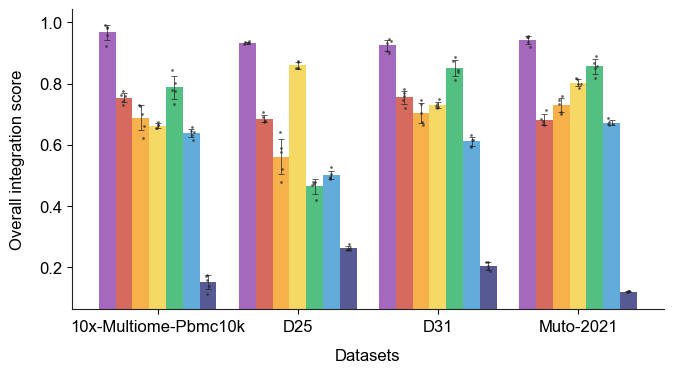

=== 各数据集-方法综合得分（均值±标准差） ===

【10x-Multiome-Pbmc10k】
- UniDISA: 0.9682 ± 0.0248
- MaxFuse: 0.7541 ± 0.0156
- scConfluence: 0.6878 ± 0.041
- BindSC: 0.6625 ± 0.0075
- GLUE: 0.7876 ± 0.0366
- Seurat: 0.6382 ± 0.014
- Uniport: 0.1501 ± 0.0229

【D25】
- UniDISA: 0.9336 ± 0.0026
- MaxFuse: 0.6852 ± 0.0121
- scConfluence: 0.5611 ± 0.057
- BindSC: 0.8602 ± 0.011
- GLUE: 0.4636 ± 0.023
- Seurat: 0.5019 ± 0.014
- Uniport: 0.2615 ± 0.0066

【D31】
- UniDISA: 0.9249 ± 0.0181
- MaxFuse: 0.7556 ± 0.0209
- scConfluence: 0.7042 ± 0.0315
- BindSC: 0.7304 ± 0.0109
- GLUE: 0.8509 ± 0.0271
- Seurat: 0.611 ± 0.0151
- Uniport: 0.2036 ± 0.0122

【Muto-2021】
- UniDISA: 0.9435 ± 0.0134
- MaxFuse: 0.6822 ± 0.0171
- scConfluence: 0.7299 ± 0.0223
- BindSC: 0.8034 ± 0.0118
- GLUE: 0.8566 ± 0.0236
- Seurat: 0.6728 ± 0.0076
- Uniport: 0.1199 ± 0.0011


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns  # 导入seaborn用于样式设置
from matplotlib.lines import Line2D

# =====================================================
# 1. 应用用户指定的样式设置（优先执行，确保全局生效）
# =====================================================
# seaborn样式：白色背景（无默认网格）
# sns.set(style='white')

# 字号配置（用户指定）
TINY_SIZE = 12
SMALL_SIZE = 12
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

# 应用matplotlib字体大小配置
plt.rc('font', size=TINY_SIZE)          # 全局默认字号
plt.rc('axes', titlesize=BIGGER_SIZE)   # 子图标题字号
plt.rc('axes', labelsize=MEDIUM_SIZE)   # x/y轴标签字号
plt.rc('xtick', labelsize=TINY_SIZE)    # x轴刻度字号
plt.rc('ytick', labelsize=TINY_SIZE)    # y轴刻度字号
plt.rc('legend', fontsize=MEDIUM_SIZE)  # 图例字号
plt.rc('figure', titlesize=BIGGER_SIZE) # 整体图标题字号（若需）

# 字体家族：Arial（用户指定）
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['axes.unicode_minus'] = False  # 解决负号显示异常

# =====================================================
# 2. 核心函数（新增综合得分计算）
# =====================================================
def min_max_normalize(series):
    """min-max归一化（x∈[0,1]），处理max=min情况"""
    min_val, max_val = series.min(), series.max()
    return pd.Series(0.5, index=series.index) if max_val == min_val else (series - min_val) / (max_val - min_val)

def process_single_repeat(df, top8_indicators, category_to_indicators, METHOD_ORDER):
    """单轮repeat处理：筛选方法→归一化→算类别均值→新增综合得分"""
    # 1. 筛选有效方法行（排除Metric Type）
    df_methods = df[df["Embedding"].isin(METHOD_ORDER)].reset_index(drop=True)
    
    # 2. 前8指标归一化
    normalized = df_methods[["Embedding"]].copy()
    for ind in top8_indicators:
        normalized[ind] = min_max_normalize(df_methods[ind])
    
    # 3. 计算类别均值（Bio conservation + Batch correction）
    cat_mean = normalized[["Embedding"]].copy()
    for cat, inds in category_to_indicators.items():
        cat_mean[f"{cat}（均值）"] = normalized[inds].mean(axis=1)
    
    # 4. 新增：计算Overall integration score（核心新增步骤）
    # 公式：0.6×生物保守性均值 + 0.4×批次校正均值
    cat_mean["Overall integration score"] = (
        0.6 * cat_mean["Bio conservation（均值）"] + 
        0.4 * cat_mean["Batch correction（均值）"]
    )
    
    return normalized, cat_mean  # 返回的cat_mean包含综合得分

def process_dataset(file_path, N_REPEAT, top8_indicators, category_to_indicators, METHOD_ORDER):
    """完整数据集处理：循环repeat→合并→验证（含综合得分）"""
    all_cat_mean = []
    for r in range(1, N_REPEAT + 1):
        df = pd.read_excel(file_path, sheet_name=f"repeat_{r}")
        _, cat_mean_df = process_single_repeat(df, top8_indicators, category_to_indicators, METHOD_ORDER)
        cat_mean_df["Repeat"] = r  # 标记轮次
        all_cat_mean.append(cat_mean_df)
        
        # 归一化验证（原有逻辑不变）
        norm_vals = process_single_repeat(df, top8_indicators, category_to_indicators, METHOD_ORDER)[0][top8_indicators].values
        assert (norm_vals >= 0).all() and (norm_vals <= 1.0001).all(), f"数据集{file_path}的repeat_{r}归一化异常"
    
    # 合并数据并验证（新增：确认综合得分列存在）
    combined_cat_mean = pd.concat(all_cat_mean, ignore_index=True)
    assert len(combined_cat_mean) == 35, f"数据集{file_path}数据量异常（预期35行，实际{len(combined_cat_mean)}行）"
    assert "Overall integration score" in combined_cat_mean.columns, "综合得分列未生成！"
    
    return combined_cat_mean

# =====================================================
# 3. 全局配置（4数据集路径+固定参数，已更新数据集名称）
# =====================================================
datasets = [
    {
        "name": "10x-Multiome-Pbmc10k",  # 数据集1名称（子图标题）
        "file_path": r"D:\Scunpair_Project\Benchmark_result(strong_5repeat)\10x-Multiome-Pbmc10k\bio_bc.xlsx"
    },
    {
        "name": "D25",   # 数据集2名称（需替换为实际名称）
        "file_path": r"D:\Scunpair_Project\Benchmark_result(strong_5repeat)\D25\bio_bc.xlsx"
    },
    {
        "name": "D31",       # 数据集3名称（需替换为实际名称）
        "file_path": r"D:\Scunpair_Project\Benchmark_result(strong_5repeat)\D31\bio_bc.xlsx"
    },
    {
        "name": "Muto-2021",     # 数据集4名称（需替换为实际名称）
        "file_path": r"D:\Scunpair_Project\Benchmark_result(strong_5repeat)\Muto-2021\bio_bc.xlsx"
    }
]

# 通用参数（与数据结构匹配）
N_REPEAT = 5
METHOD_ORDER = ["UniDISA", "MaxFuse", "scConfluence", "BindSC", "GLUE", "Seurat", "Uniport"]
top8_indicators = [
    "Isolated labels", "KMeans NMI", "KMeans ARI", "cLISI",
    "BRAS", "iLISI", "KBET", "Graph connectivity"
]
category_to_indicators = {
    "Bio conservation": ["Isolated labels", "KMeans NMI", "KMeans ARI", "cLISI"],
    "Batch correction": ["BRAS", "iLISI", "KBET", "Graph connectivity"]
}

# 固定颜色面板（突出UniDISA）
fixed_color_palette = {
    'UniDISA':'#8E44AD' ,    # 紫色（突出）
    'MaxFuse': '#CD4537',    # 红色
    'scConfluence': '#F59E1D',# 橙色
    'BindSC': '#F4D03E',     # 黄色
    'GLUE': '#28AF60',       # 绿色
    'Seurat': '#3A97D2',     # 天蓝色
    'Uniport': '#2C3078'     # 深蓝色
}
# =====================================================
# 4. 批量处理4个数据集（带容错，验证综合得分）
# =====================================================
dataset_results = []
for ds in datasets:
    print(f"正在处理数据集：{ds['name']}")
    try:
        combined_cat_mean = process_dataset(
            file_path=ds["file_path"],
            N_REPEAT=N_REPEAT,
            top8_indicators=top8_indicators,
            category_to_indicators=category_to_indicators,
            METHOD_ORDER=METHOD_ORDER
        )
        dataset_results.append({"name": ds["name"], "data": combined_cat_mean})
        
        # 打印部分结果，验证综合得分（可选，用于确认）
        print(f"✅ 数据集{ds['name']}处理完成，前3行综合得分预览：")
        preview_cols = ["Embedding", "Repeat", "Bio conservation（均值）", "Batch correction（均值）", "Overall integration score"]
        print(combined_cat_mean[preview_cols].head(3).round(4))
        print()
    except Exception as e:
        print(f"❌ 数据集{ds['name']}处理失败：{str(e)}\n")

if not dataset_results:
    raise ValueError("所有数据集处理失败，请检查路径和数据格式！")

# =====================================================
# 5. （可选）生成综合得分统计摘要（按数据集+方法分组）
# =====================================================
print("=== 各数据集-方法综合得分统计摘要（均值±标准差） ===")
for ds_res in dataset_results:
    ds_name = ds_res["name"]
    ds_data = ds_res["data"]
    # 按方法分组，计算综合得分的均值和标准差
    score_stats = ds_data.groupby("Embedding")["Overall integration score"].agg(["mean", "std"]).round(4)
    score_stats["mean±std"] = score_stats["mean"].astype(str) + "±" + score_stats["std"].astype(str)
    print(f"\n【{ds_name}】")
    print(score_stats["mean±std"])


# 固定颜色面板（与示例图风格一致，突出UniDISA）
fixed_color_palette = {
    'UniDISA':'#8E44AD' ,    # 紫色（突出）
    'MaxFuse': '#CD4537',    # 红色
    'scConfluence': '#F59E1D',# 橙色
    'BindSC': '#F4D03E',     # 黄色
    'GLUE': '#28AF60',       # 绿色
    'Seurat': '#3A97D2',     # 天蓝色
    'Uniport': '#2C3078'     # 深蓝色
}
METHOD_ORDER = ["UniDISA", "MaxFuse", "scConfluence", "BindSC", "GLUE", "Seurat", "Uniport"]


# =====================================================
# 2. 整理数据：保留每个repeat的原始综合得分（核心修改）
# =====================================================
# 存储结构：{数据集名称: {方法: [所有repeat的综合得分]}}
plot_data = {}
for ds_res in dataset_results:
    ds_name = ds_res["name"]
    ds_data = ds_res["data"]
    
    # 按方法分组，提取每个方法的所有repeat综合得分
    method_repeats = {}
    for method in METHOD_ORDER:
        # 获取当前方法的5个repeat综合得分
        repeats = ds_data[ds_data["Embedding"] == method]["Overall integration score"].values
        method_repeats[method] = repeats
    
    plot_data[ds_name] = method_repeats

# 提取数据集列表（保持输入顺序）
dataset_names = [ds["name"] for ds in datasets if ds["name"] in plot_data.keys()]
n_datasets = len(dataset_names)
n_methods = len(METHOD_ORDER)
n_repeats = 5  # 每个方法5个repeat


# =====================================================
# 3. 绘制示例图风格的柱状图（柱子+误差线+repeat散点）
# =====================================================
# 柱子宽度与间距（匹配示例图的紧凑布局）
bar_width = 0.12
group_gap = 0.3
x_base = np.arange(n_datasets)  # 每个数据集的基准x坐标

fig, ax = plt.subplots(figsize=(8, 4))

# 循环绘制每个方法的元素（柱子+误差线+repeat散点）
for method_idx, method in enumerate(METHOD_ORDER):
    # 计算当前方法在每个数据集的x坐标（组内偏移）
    x_pos = x_base + (method_idx - (n_methods - 1) / 2) * bar_width
    
    # 收集当前方法在各数据集的：原始得分、均值、标准差
    all_repeats = []  # 所有数据集的repeat得分（二维列表）
    means = []
    stds = []
    for ds_name in dataset_names:
        repeats = plot_data[ds_name][method]
        all_repeats.append(repeats)
        means.append(np.mean(repeats))
        stds.append(np.std(repeats))
    
    # 1. 绘制均值柱子（无明显边框，匹配示例图）
    ax.bar(
        x_pos, means, bar_width,
        color=fixed_color_palette[method],
        alpha=0.8,
        edgecolor='none',  # 取消柱子边框，和示例图一致
        linewidth=0
    )
    
    # 2. 绘制误差线（细线条，匹配示例图）
    ax.errorbar(
        x_pos, means, yerr=stds,
        fmt='none',  # 不画额外线条，仅保留误差线
        color='#222222',
        capsize=2,   # 误差线帽更短
        capthick=0.5,
        elinewidth=0.5
    )
    
    # 3. 绘制每个repeat的原始数据点（核心：匹配示例图的散点式误差展示）
    for ds_idx, ds_repeats in enumerate(all_repeats):
        # 每个repeat的x坐标（在柱子上方轻微分散，避免重叠）
        point_x = x_pos[ds_idx] + np.random.normal(0, 0.01, n_repeats)  # 轻微抖动
        ax.scatter(
            point_x, ds_repeats,
            color='#222222',  # 黑色小散点，和示例图一致
            s=15,             # 散点大小
            alpha=0.7,
            marker='.',       # 小圆点
            linewidth=0
        )


# =====================================================
# 4. 图表细节（匹配示例图布局）
# =====================================================
ax.set_xlabel("Datasets", fontsize=MEDIUM_SIZE, labelpad=10)
ax.set_ylabel("Overall integration score", fontsize=MEDIUM_SIZE, labelpad=10)

# 横坐标标签（水平显示）
ax.set_xticks(x_base)
ax.set_xticklabels(dataset_names, rotation=0)

# 纵坐标范围（匹配数据分布）
all_scores = [score for ds in plot_data.values() for method in ds.values() for score in method]
y_min = min(all_scores) - 0.05
y_max = max(all_scores) + 0.05
ax.set_ylim(y_min, y_max)

# 边框优化（仅左下边框）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')

# 图例（右侧中间）
# ax.legend(
#     handles=[plt.Rectangle((0,0),1,1, color=fixed_color_palette[m], alpha=0.8) for m in METHOD_ORDER],
#     labels=METHOD_ORDER,
#     loc='lower center',
#     bbox_to_anchor=(0.5, -0.3),
#     ncol=7,
#     framealpha=0.9,
#     edgecolor='#DDDDDD',
#     title="Methods"
# )

# 调整布局（给图例留空间）
plt.subplots_adjust(left=0.08, right=0.82, top=0.9, bottom=0.15)


plt.savefig(
    "Fig2b.jpg",
    dpi=500,
    bbox_inches='tight',
    facecolor='white',
    edgecolor='none'
)

# 显示图表
plt.show()


# =====================================================
# 数据摘要（核对用）
# =====================================================
print("=== 各数据集-方法综合得分（均值±标准差） ===")
for ds_name in dataset_names:
    print(f"\n【{ds_name}】")
    for method in METHOD_ORDER:
        repeats = plot_data[ds_name][method]
        mean = np.mean(repeats).round(4)
        std = np.std(repeats).round(4)
        print(f"- {method}: {mean} ± {std}")